# Zipf 則を確認してみよう

In [4]:
! pip install mecab-python3 unidic-lite
import MeCab

# 描画
import matplotlib.pyplot as plt

# 単語カウント
from collections import Counter

In [3]:
# load data 
def remove_punctuation(text):
    # 句読点を削除する関数
    punctuation = "，．、。！？「」（）『』【】《》〈〉…"
    for p in punctuation:
        text = text.replace(p, "")
    return text


def read_dataset(file_path):
    # 複数の行に分かれた日本語文を読み込み，単語ごとに分割してリストに格納し，generatorで返す
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            # MeCabを用いて単語に分割
            mecab = MeCab.Tagger("-Owakati")
            words = mecab.parse(line)
            words = remove_punctuation(words).strip().split()
            yield words

# データセットの読み込み
data = list(read_dataset("data.txt"))
print(data[:2])

[['水', 'を', 'マレーシア', 'から', '買わ', 'なく', 'て', 'は', 'なら', 'ない', 'の', 'です'], ['木曜', '日', '停戦', '会談', 'は', '何', 'の', '進展', 'も', 'ない', 'まま', '終了', 'し', 'まし', 'た']]


In [34]:
# 単語の出現頻度をカウント
counter = Counter()
for words in data:
    counter.update(words)

print("上位10件:")
print(counter.most_common(10))
print("下位10件:")
print(counter.most_common()[-10:])

上位10件:
[('の', 4464), ('に', 4010), ('は', 3486), ('を', 3341), ('て', 2818), ('が', 2728), ('た', 2469), ('で', 1981), ('と', 1684), ('し', 1357)]
下位10件:
[('艶', 1), ('弾劾', 1), ('ひらか', 1), ('扇型', 1), ('弧', 1), ('嗣子', 1), ('震え上がっ', 1), ('ドナー', 1), ('腎臓', 1), ('猶予', 1)]


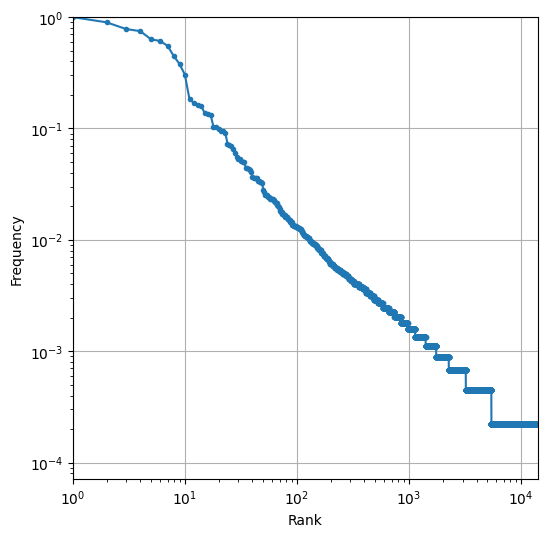

In [32]:
# counter を描画
ranks = range(1, len(counter) + 1) # 単語の順位
max_freq = counter.most_common(1)[0][1]
frequencies = [freq / max_freq for _, freq in counter.most_common()] # 頻度を正規化
plt.figure(figsize=(6, 6)) 
plt.loglog(ranks, frequencies, marker=".")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.xlim(1, len(counter))
plt.ylim(1 / len(counter), 1)

plt.grid()
plt.show()  